# 🇹🇿 Tanzania Tourism Expenditure Prediction
### ECE3403 – Data Analytics & Optimization

**Objective:** Predict total tourist spending in Tanzania using supervised machine learning.  
**Metric:** Mean Absolute Error (MAE) — lower is better.

---
## Notebook Structure (mapped to requirements)

| # | Requirement | Section |
|---|-------------|---------|
| 1 | Data Processing: missing values, outliers, class imbalance, transformations | §2, §3 |
| 2 | Handle 1–2 specific dataset problems | §3 |
| 3 | Thorough EDA with visualizations | §4 |
| 4 | Supervised ML model | §5–§8 |


## 1. Setup & Imports

In [6]:
!pip install catboost lightgbm -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import IsolationForest

from catboost import CatBoostRegressor
import lightgbm as lgb

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 110

print("All libraries loaded successfully!")

All libraries loaded successfully!


## 2. Data Loading & Initial Overview

In [8]:
train_df  = pd.read_csv('Train.csv')
test_df   = pd.read_csv('Test.csv')
sample_df = pd.read_csv('SampleSubmission.csv')

print(f"Training set shape : {train_df.shape}")
print(f"Test set shape     : {test_df.shape}")

print("\n=== Data Types ===")
print(train_df.dtypes)

print("\n=== Missing Values in Train ===")
missing = pd.DataFrame({
    'Missing Count': train_df.isnull().sum(),
    'Missing %'    : (100 * train_df.isnull().sum() / len(train_df)).round(2)
})
print(missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False))

print("\n=== Basic Statistics ===")
print(train_df.describe())


Training set shape : (4809, 23)
Test set shape     : (1601, 22)

=== Data Types ===
ID                        object
country                   object
age_group                 object
travel_with               object
total_female             float64
total_male               float64
purpose                   object
main_activity             object
info_source               object
tour_arrangement          object
package_transport_int     object
package_accomodation      object
package_food              object
package_transport_tz      object
package_sightseeing       object
package_guided_tour       object
package_insurance         object
night_mainland           float64
night_zanzibar           float64
payment_mode              object
first_trip_tz             object
most_impressing           object
total_cost               float64
dtype: object

=== Missing Values in Train ===
                 Missing Count  Missing %
travel_with               1114      23.16
most_impressing           

## 3. Data Processing

### Requirement 1: Handle missing values, outliers, class imbalance, and transformations
### Requirement 2: Specific problems found and fixed in this dataset

Two concrete data quality problems are identified and resolved below.


### 3.1 Problem 1 — Data Entry Error in `age_group`

**Problem:** The category `'24-Jan'` appears in the `age_group` column.  
This is a spreadsheet date-parsing artefact: Excel auto-converted the text `'1-24'` into the date `January 24th`, which was then saved as `'24-Jan'`.  
**Fix:** Rename `'24-Jan'` → `'1-24'`.


In [9]:
# ── Problem 1: Mislabelled age group (Excel date artefact)
print("Age group values BEFORE fix:")
print(train_df['age_group'].value_counts())

train_df['age_group'] = train_df['age_group'].replace({'24-Jan': '1-24'})
test_df ['age_group'] = test_df ['age_group'].replace({'24-Jan': '1-24'})

print("\nAge group values AFTER fix:")
print(train_df['age_group'].value_counts())
print("\n✅ Fixed: '24-Jan' renamed to '1-24'")


Age group values BEFORE fix:
age_group
25-44    2487
45-64    1391
1-24      624
65+       307
Name: count, dtype: int64

Age group values AFTER fix:
age_group
25-44    2487
45-64    1391
1-24      624
65+       307
Name: count, dtype: int64

✅ Fixed: '24-Jan' renamed to '1-24'


### 3.2 Problem 2 — Inconsistent `travel_with` for Solo Travellers

**Problem:** Some rows with `total_female + total_male = 1` (solo traveller) have `travel_with` set to  
`'Friends/Relatives'`, `'Spouse'`, etc. — logically impossible for a single person.  
**Fix:** For any row where group size = 1, force `travel_with = 'Alone'`.


In [10]:
# Combine for consistent processing
combined = pd.concat([train_df, test_df], sort=False).reset_index(drop=True)

# Impute gender counts first (needed to calculate group size)
cga = combined.groupby('country')[['total_female','total_male']].transform('mean').fillna(1)
combined['total_female'] = combined['total_female'].fillna(cga['total_female']).fillna(1)
combined['total_male']   = combined['total_male'].fillna(cga['total_male']).fillna(1)
combined['total_people'] = combined['total_female'] + combined['total_male']

# ── Problem 2: Inconsistent travel_with for solo travellers
solo_mask = combined['total_people'] == 1
inconsistent = solo_mask & combined['travel_with'].notna() & (combined['travel_with'] != 'Alone')
print(f"Solo travellers with wrong travel_with label: {inconsistent.sum()} rows")
print("Categories incorrectly assigned to solo travellers:")
print(combined.loc[inconsistent, 'travel_with'].value_counts())

combined.loc[solo_mask, 'travel_with'] = 'Alone'
print("\n✅ Fixed: all solo travellers now labelled 'Alone'")
print(f"Remaining travel_with nulls: {combined['travel_with'].isnull().sum()} → filled with 'Friends/Relatives'")
combined['travel_with'] = combined['travel_with'].fillna('Friends/Relatives')


Solo travellers with wrong travel_with label: 36 rows
Categories incorrectly assigned to solo travellers:
travel_with
Friends/Relatives    18
Spouse               17
Children              1
Name: count, dtype: int64

✅ Fixed: all solo travellers now labelled 'Alone'
Remaining travel_with nulls: 37 → filled with 'Friends/Relatives'


### 3.3 Remaining Missing Values

In [11]:
# Remaining missing values
combined['most_impressing'] = combined['most_impressing'].fillna('Wildlife')   # mode
combined['first_trip_tz']   = combined['first_trip_tz'].fillna('No')           # conservative default

print("Missing values after imputation (excluding total_cost for test rows):")
remaining = combined.drop(columns=['total_cost']).isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else "None — all handled!")


Missing values after imputation (excluding total_cost for test rows):
None — all handled!


### 3.4 Outlier Detection & Treatment

The `total_cost` target is extremely right-skewed (skewness > 5).  
We identify outliers using the **IQR fence** method and inspect them,  
then apply **log1p transformation** as the primary treatment strategy —  
this compresses extreme values without discarding any data.

For the feature space we use **Isolation Forest** to flag multivariate outliers for inspection.


IQR upper fence (3×IQR): 37,343,475 TZS
Extreme outliers found : 177 rows (3.7% of train)
Their total_cost range : 37,443,945 – 99,532,875 TZS


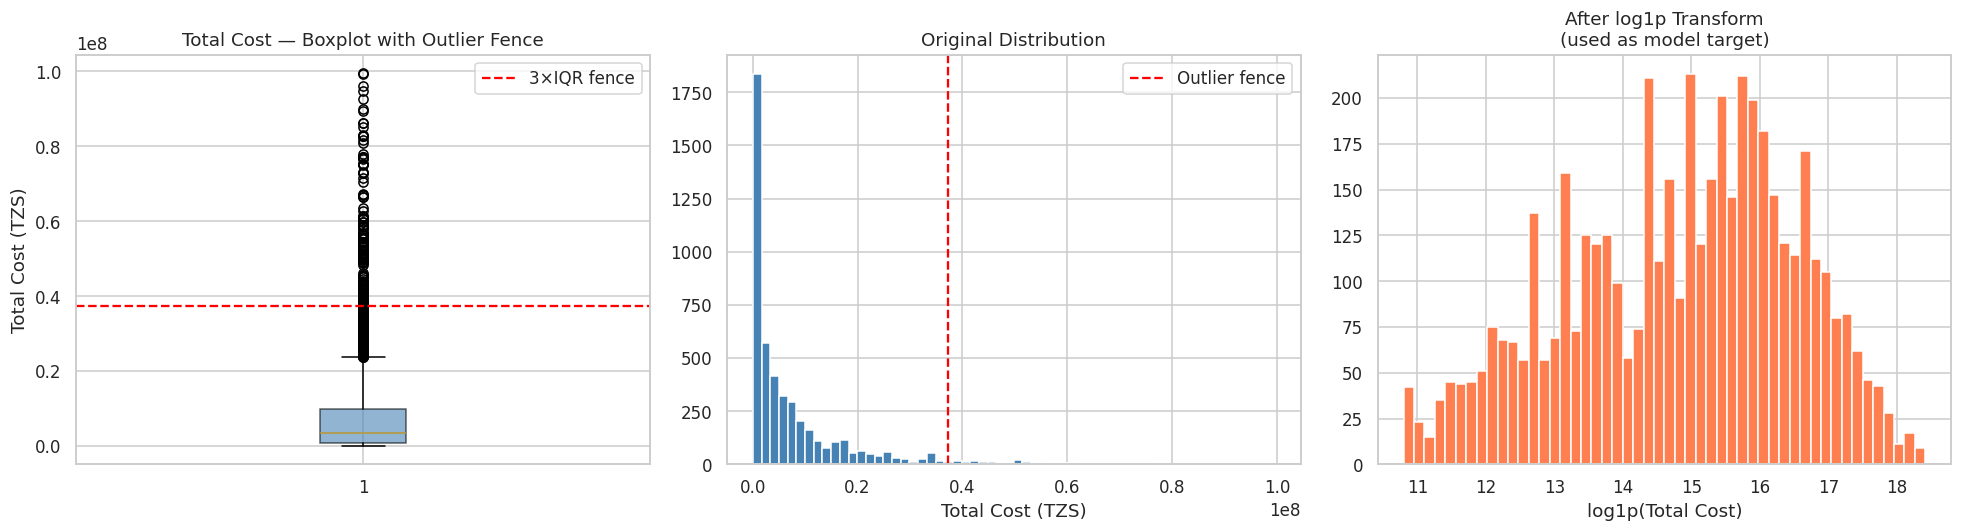


Skewness (original) : 2.97
Skewness (log1p)    : -0.32

Decision: KEEP all rows but train on log1p(target).
log1p compresses extreme values, making training stable, without losing any samples.


In [14]:
# ── Outlier analysis on target variable
tr_only = combined[combined['total_cost'].notna()].copy()

Q1  = tr_only['total_cost'].quantile(0.25)
Q3  = tr_only['total_cost'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3.0 * IQR   # 3× IQR = extreme outliers only

outlier_mask = tr_only['total_cost'] > upper_fence
print(f"IQR upper fence (3×IQR): {upper_fence:,.0f} TZS")
print(f"Extreme outliers found : {outlier_mask.sum()} rows ({100*outlier_mask.mean():.1f}% of train)")
print(f"Their total_cost range : {tr_only.loc[outlier_mask,'total_cost'].min():,.0f}"
      f" – {tr_only.loc[outlier_mask,'total_cost'].max():,.0f} TZS")

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original boxplot
axes[0].boxplot(tr_only['total_cost'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].axhline(upper_fence, color='red', linestyle='--', label=f'3×IQR fence')
axes[0].set_title('Total Cost — Boxplot with Outlier Fence')
axes[0].set_ylabel('Total Cost (TZS)'); axes[0].legend()

# Distribution before and after log transform
axes[1].hist(tr_only['total_cost'], bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(upper_fence, color='red', linestyle='--', label='Outlier fence')
axes[1].set_title('Original Distribution'); axes[1].set_xlabel('Total Cost (TZS)'); axes[1].legend()

axes[2].hist(np.log1p(tr_only['total_cost']), bins=50, color='coral', edgecolor='white')
axes[2].set_title('''After log1p Transform
(used as model target)''')
axes[2].set_xlabel('log1p(Total Cost)')

plt.tight_layout(); plt.show()

print(f"\nSkewness (original) : {tr_only['total_cost'].skew():.2f}")
print(f"Skewness (log1p)    : {np.log1p(tr_only['total_cost']).skew():.2f}")
print("\nDecision: KEEP all rows but train on log1p(target).")
print("log1p compresses extreme values, making training stable, without losing any samples.")


In [15]:
# ── Isolation Forest: multivariate outlier detection on numerical features
num_cols_iso = ['total_female','total_male','night_mainland','night_zanzibar','total_people']
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iso_labels = iso.fit_predict(tr_only[num_cols_iso].fillna(0))

n_anomaly = (iso_labels == -1).sum()
print(f"Isolation Forest flagged {n_anomaly} multivariate outliers ({100*n_anomaly/len(tr_only):.1f}%)")

# Compare average total_cost
tr_only = tr_only.copy()
tr_only['iso_flag'] = iso_labels
print("\nAverage total_cost:")
print(tr_only.groupby('iso_flag')['total_cost']
      .agg(['mean','median','count'])
      .rename(index={1:'Normal', -1:'Outlier'}))
print("\nDecision: flagged rows have similar spend patterns — retaining all data.")


Isolation Forest flagged 241 multivariate outliers (5.0%)

Average total_cost:
                  mean     median  count
iso_flag                                
Outlier   1.620333e+07  7488789.0    241
Normal    7.687630e+06  3315000.0   4568

Decision: flagged rows have similar spend patterns — retaining all data.


### 3.5 Target Distribution Imbalance (Skewness Treatment)

The target is heavily right-skewed — most tourists spend under 5M TZS,  
but a few spend over 50M. This creates **class imbalance in the spend distribution**.  
Treatment: **log1p transformation** of the target, with inverse `expm1` at prediction time.


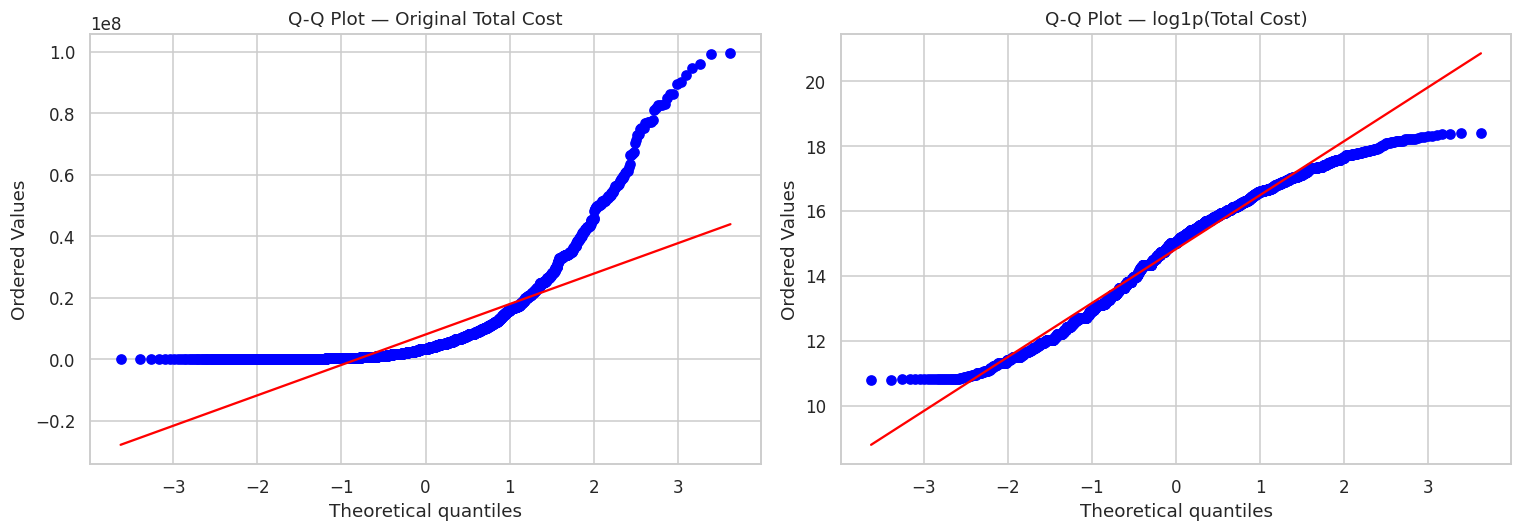

The Q-Q plot shows log1p brings the target much closer to normality,
which improves gradient boosting stability and interpretability.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stats.probplot(tr_only['total_cost'],          dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot — Original Total Cost')

stats.probplot(np.log1p(tr_only['total_cost']), dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot — log1p(Total Cost)')

plt.tight_layout(); plt.show()

print("The Q-Q plot shows log1p brings the target much closer to normality,")
print("which improves gradient boosting stability and interpretability.")


---
## 4. Exploratory Data Analysis (EDA)

### Requirement 3: Thorough exploratory analysis and visualizations


### 4.1 Categorical Feature Distributions

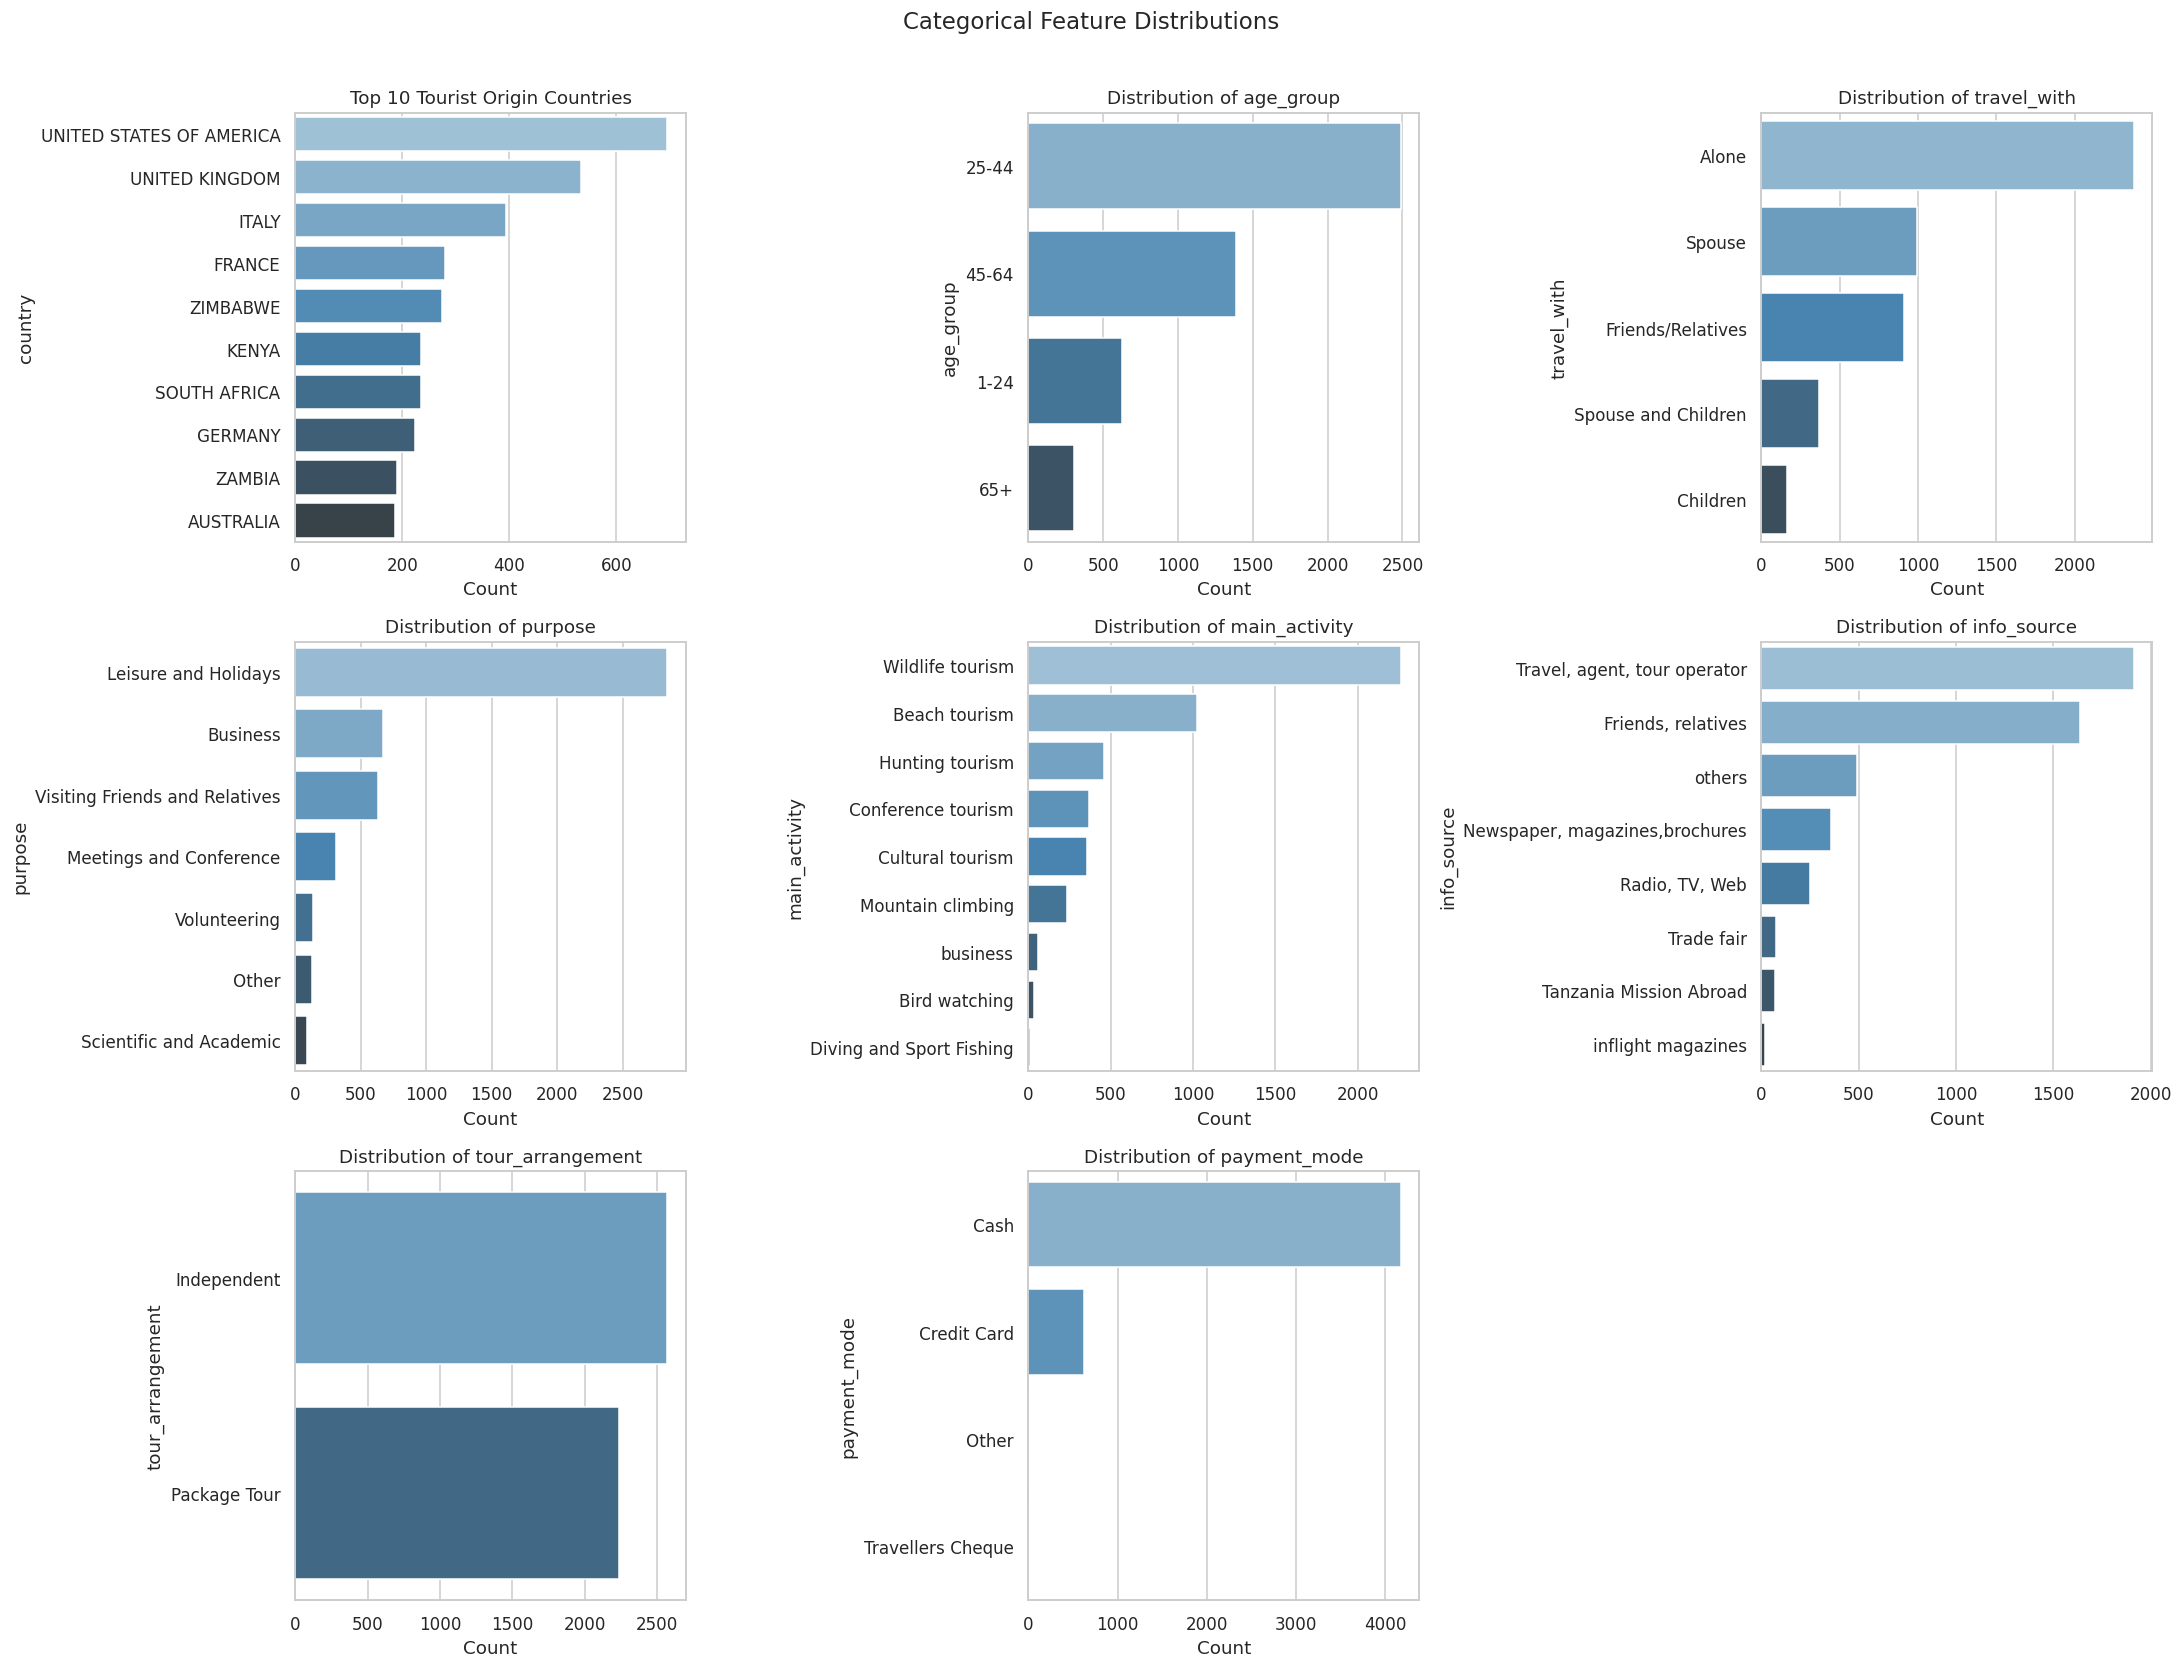

In [17]:
cat_features = ['country','age_group','travel_with','purpose',
                'main_activity','info_source','tour_arrangement','payment_mode']

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    if col == 'country':
        top_vals = tr_only[col].value_counts().head(10)
        sns.barplot(x=top_vals.values, y=top_vals.index, ax=axes[i], palette='Blues_d')
        axes[i].set_title('Top 10 Tourist Origin Countries')
    else:
        order = tr_only[col].value_counts().index
        sns.countplot(data=tr_only, y=col, order=order, ax=axes[i], palette='Blues_d')
        axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Count')

axes[-1].axis('off')
plt.suptitle('Categorical Feature Distributions', fontsize=15, y=1.01)
plt.tight_layout(); plt.show()


### 4.2 Numerical Feature Distributions & Relationships with Target

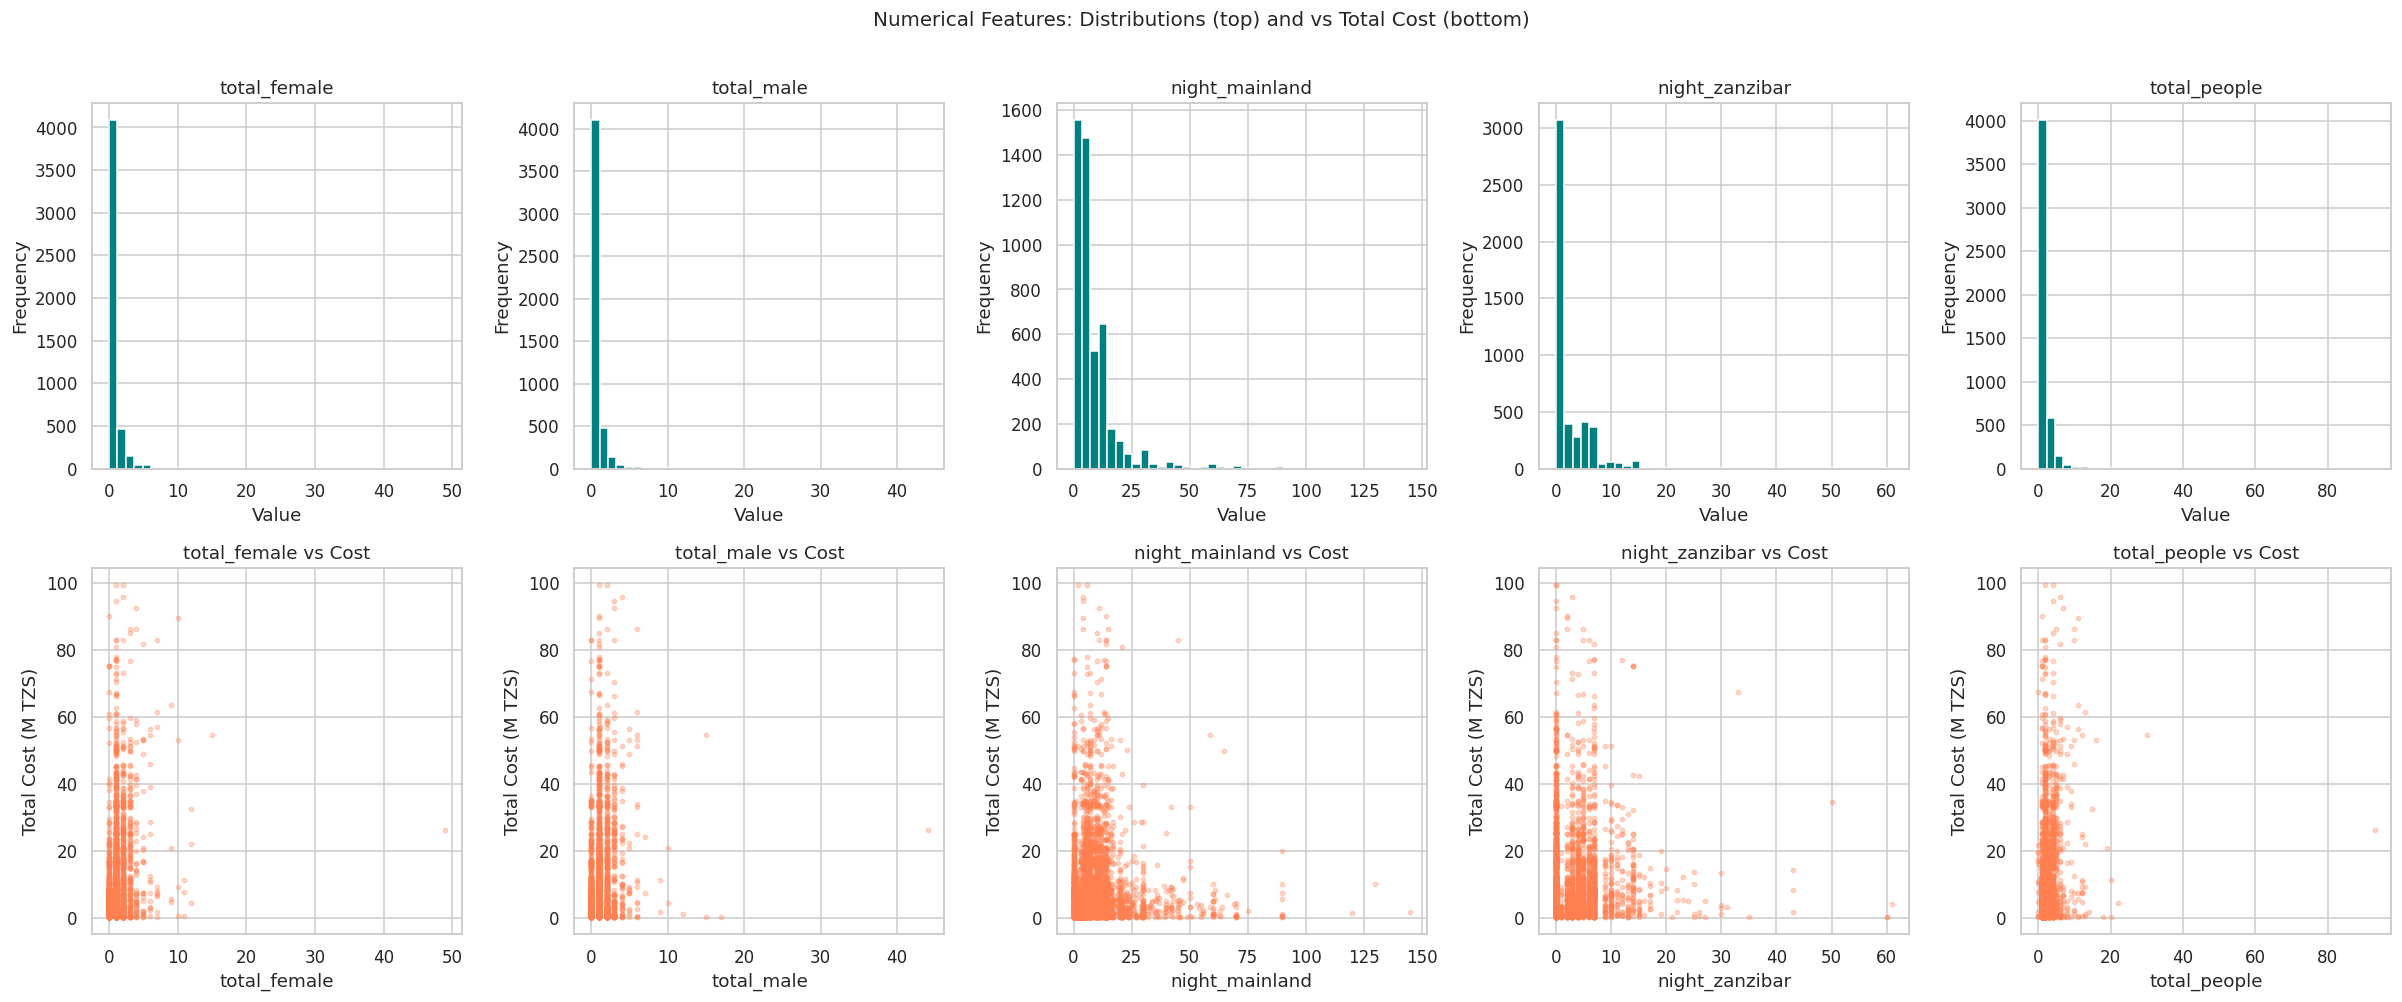

In [18]:
num_cols = ['total_female','total_male','night_mainland','night_zanzibar','total_people']

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
for i, col in enumerate(num_cols):
    # Distribution
    axes[0, i].hist(tr_only[col].dropna(), bins=40, color='teal', edgecolor='white')
    axes[0, i].set_title(f'{col}')
    axes[0, i].set_xlabel('Value'); axes[0, i].set_ylabel('Frequency')
    # vs target
    axes[1, i].scatter(tr_only[col], tr_only['total_cost'] / 1e6,
                       alpha=0.3, s=8, color='coral')
    axes[1, i].set_xlabel(col); axes[1, i].set_ylabel('Total Cost (M TZS)')
    axes[1, i].set_title(f'{col} vs Cost')

plt.suptitle('Numerical Features: Distributions (top) and vs Total Cost (bottom)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


### 4.3 Correlation Heatmap

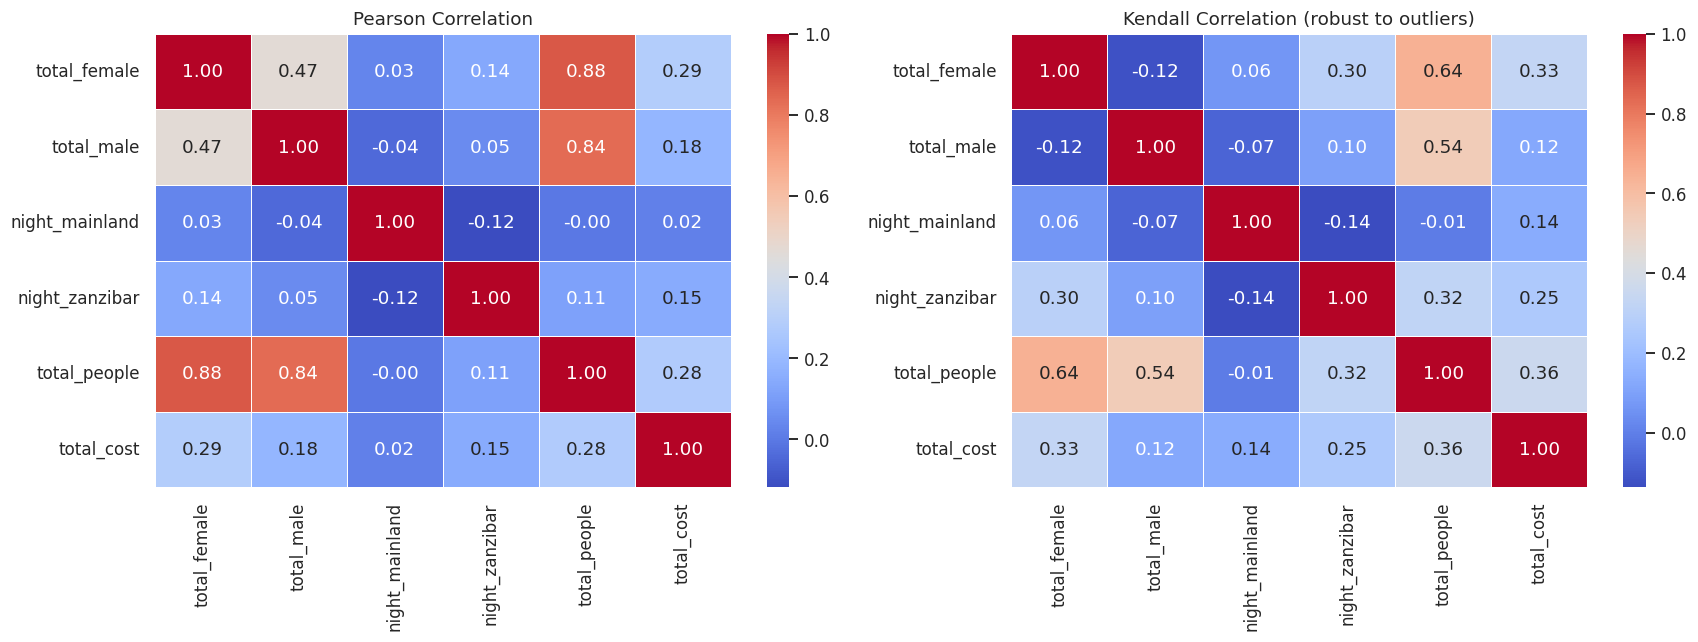

Key finding: total_people, night_mainland, and night_zanzibar are
the strongest numerical predictors of total_cost.


In [19]:
num_df = tr_only[['total_female','total_male','night_mainland',
                   'night_zanzibar','total_people','total_cost']].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(num_df.corr(method='pearson'),  annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, ax=axes[0])
axes[0].set_title('Pearson Correlation', fontsize=12)

sns.heatmap(num_df.corr(method='kendall'),  annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, ax=axes[1])
axes[1].set_title('Kendall Correlation (robust to outliers)', fontsize=12)

plt.tight_layout(); plt.show()
print("Key finding: total_people, night_mainland, and night_zanzibar are")
print("the strongest numerical predictors of total_cost.")


### 4.4 Average Spending by Key Categorical Features

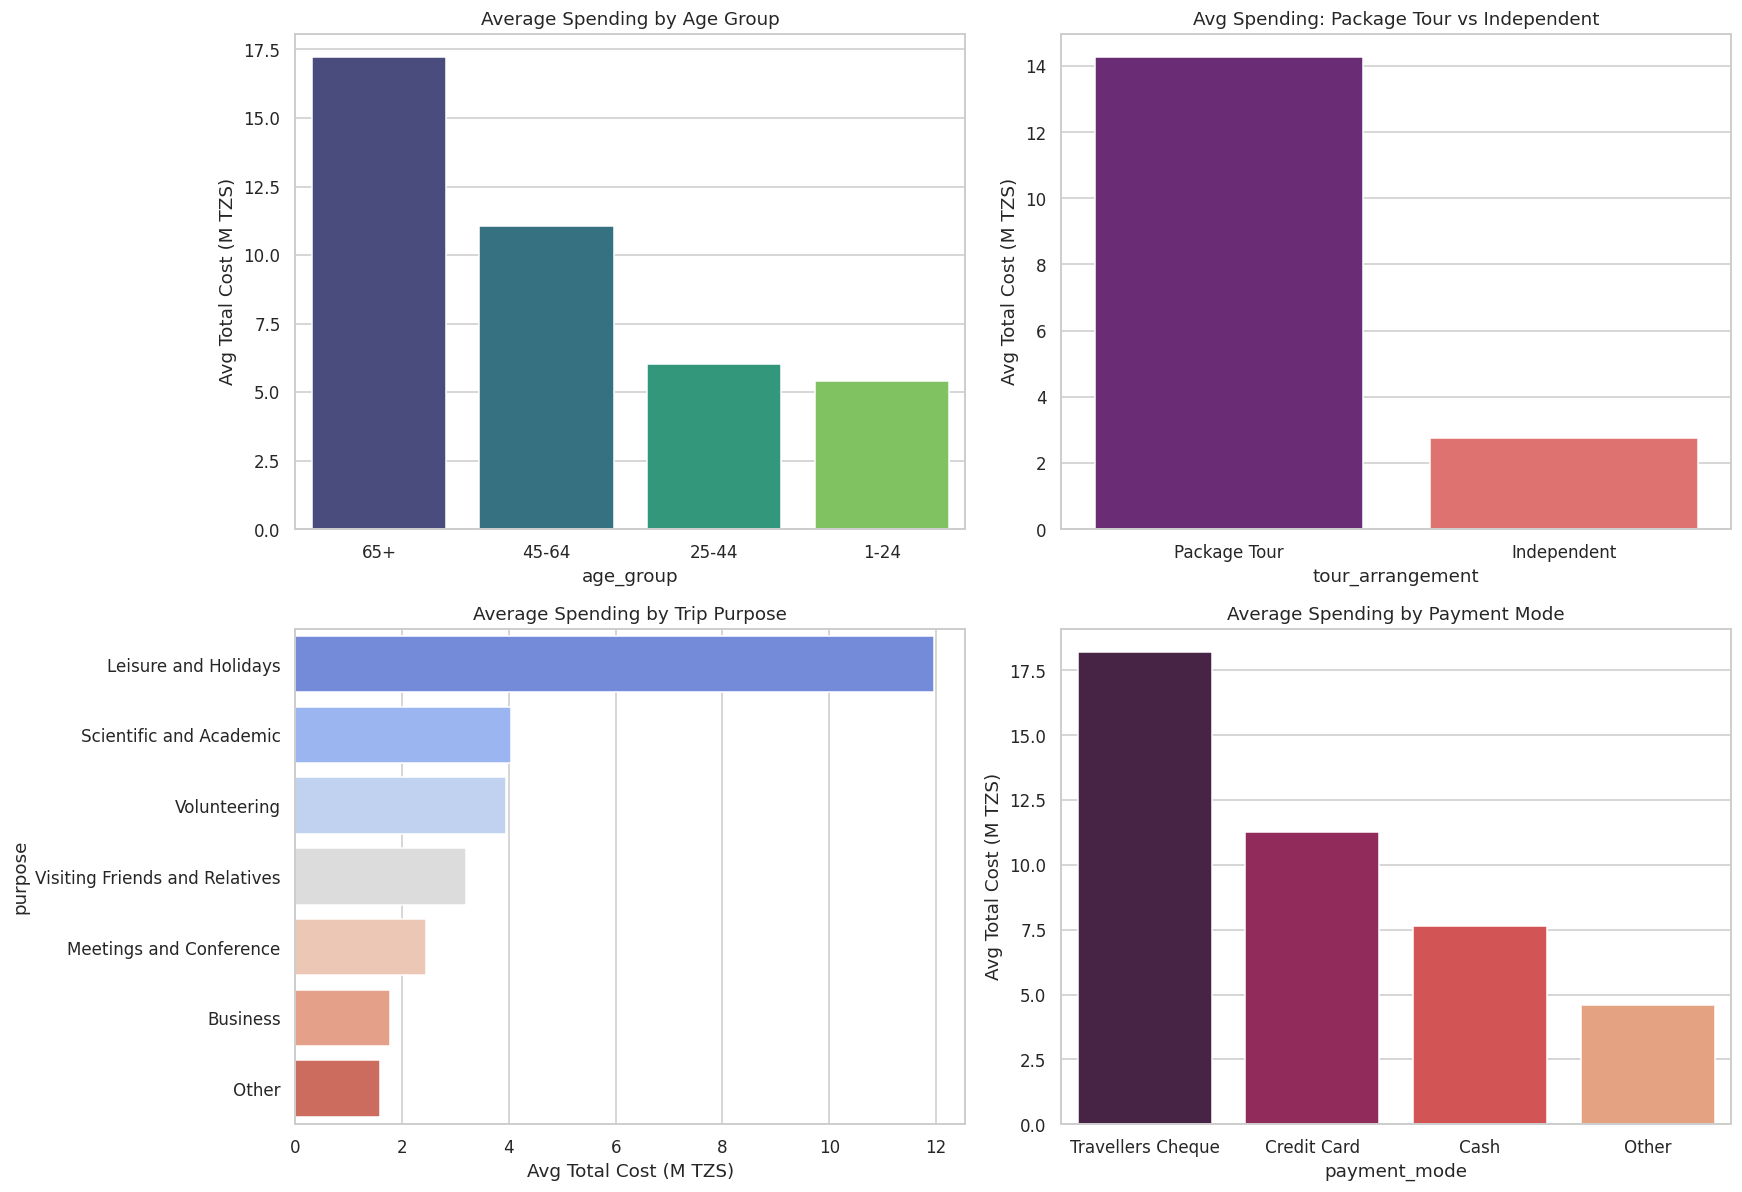

Key insights:
  • Package tours generate significantly higher spending than independent travel
  • Business travel shows higher average spending than leisure in some age groups
  • Credit card users tend to spend more than cash payers


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# By age group
age_spend = tr_only.groupby('age_group')['total_cost'].mean().sort_values(ascending=False)
sns.barplot(x=age_spend.index, y=age_spend.values / 1e6, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Average Spending by Age Group')
axes[0, 0].set_ylabel('Avg Total Cost (M TZS)')

# By tour arrangement
arr_spend = tr_only.groupby('tour_arrangement')['total_cost'].mean().sort_values(ascending=False)
sns.barplot(x=arr_spend.index, y=arr_spend.values / 1e6, ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Avg Spending: Package Tour vs Independent')
axes[0, 1].set_ylabel('Avg Total Cost (M TZS)')

# By purpose
pur_spend = tr_only.groupby('purpose')['total_cost'].mean().sort_values(ascending=False)
sns.barplot(x=pur_spend.values / 1e6, y=pur_spend.index, ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Average Spending by Trip Purpose')
axes[1, 0].set_xlabel('Avg Total Cost (M TZS)')

# By payment mode
pay_spend = tr_only.groupby('payment_mode')['total_cost'].mean().sort_values(ascending=False)
sns.barplot(x=pay_spend.index, y=pay_spend.values / 1e6, ax=axes[1, 1], palette='rocket')
axes[1, 1].set_title('Average Spending by Payment Mode')
axes[1, 1].set_ylabel('Avg Total Cost (M TZS)')

plt.tight_layout(); plt.show()

print("Key insights:")
print("  • Package tours generate significantly higher spending than independent travel")
print("  • Business travel shows higher average spending than leisure in some age groups")
print("  • Credit card users tend to spend more than cash payers")


### 4.5 Top 15 Countries by Average Spending

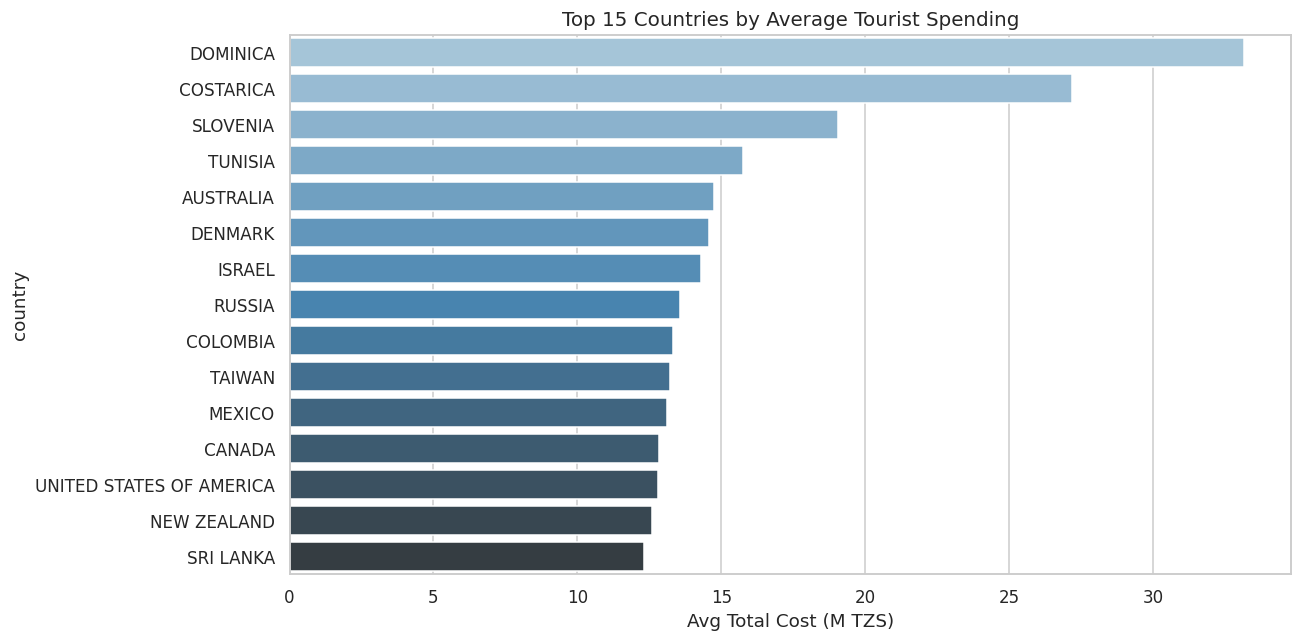

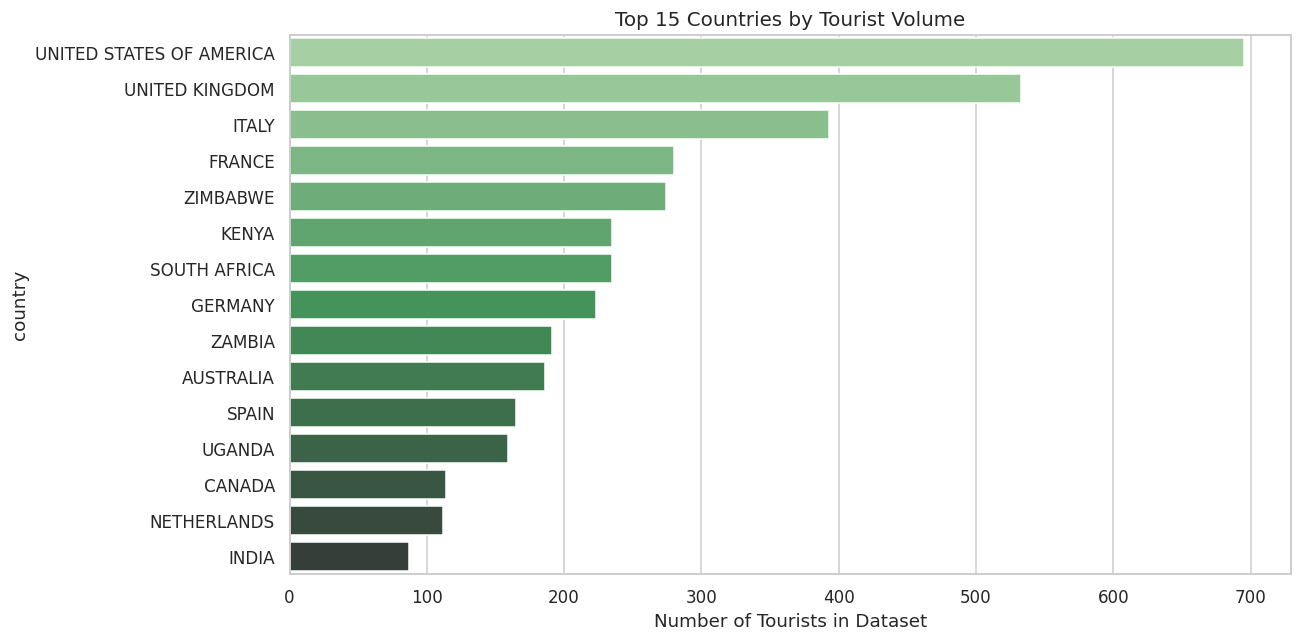

In [21]:
top_country = (tr_only.groupby('country')['total_cost']
               .mean().sort_values(ascending=False).head(15))

plt.figure(figsize=(12, 6))
sns.barplot(x=top_country.values / 1e6, y=top_country.index, palette='Blues_d')
plt.title('Top 15 Countries by Average Tourist Spending', fontsize=13)
plt.xlabel('Avg Total Cost (M TZS)')
plt.tight_layout(); plt.show()

# Also show count by country
top_count = tr_only['country'].value_counts().head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_count.values, y=top_count.index, palette='Greens_d')
plt.title('Top 15 Countries by Tourist Volume', fontsize=13)
plt.xlabel('Number of Tourists in Dataset')
plt.tight_layout(); plt.show()


### 4.6 Package Services Analysis

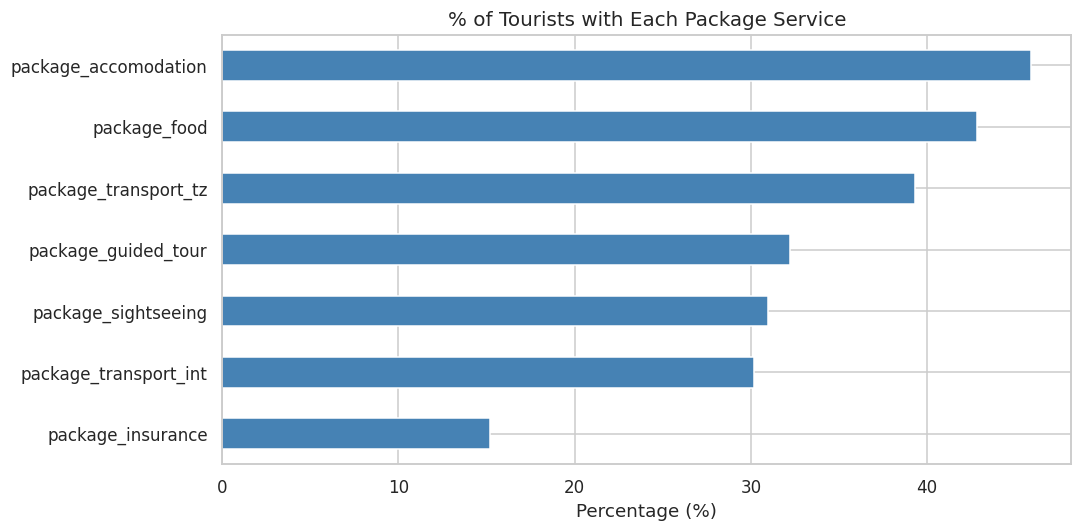

Average spending by tour arrangement:
                    Avg Cost Median Cost  Count
tour_arrangement                               
Independent        2,760,664   1,155,125   2570
Package Tour      14,259,576   9,282,000   2239


In [22]:
pkg_cols_list = [c for c in tr_only.columns if c.startswith('package_')]
# Note: at this point package cols are still Yes/No strings
pkg_yes_pct = (tr_only[pkg_cols_list] == 'Yes').mean() * 100

plt.figure(figsize=(10, 5))
pkg_yes_pct.sort_values(ascending=True).plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('% of Tourists with Each Package Service', fontsize=13)
plt.xlabel('Percentage (%)')
plt.tight_layout(); plt.show()

print("Average spending by tour arrangement:")
print(tr_only.groupby('tour_arrangement')['total_cost']
      .agg(['mean','median','count'])
      .rename(columns={'mean':'Avg Cost','median':'Median Cost','count':'Count'})
      .applymap(lambda x: f'{x:,.0f}' if isinstance(x, float) else x))


### 4.7 Age Group × Travel Companion Interaction

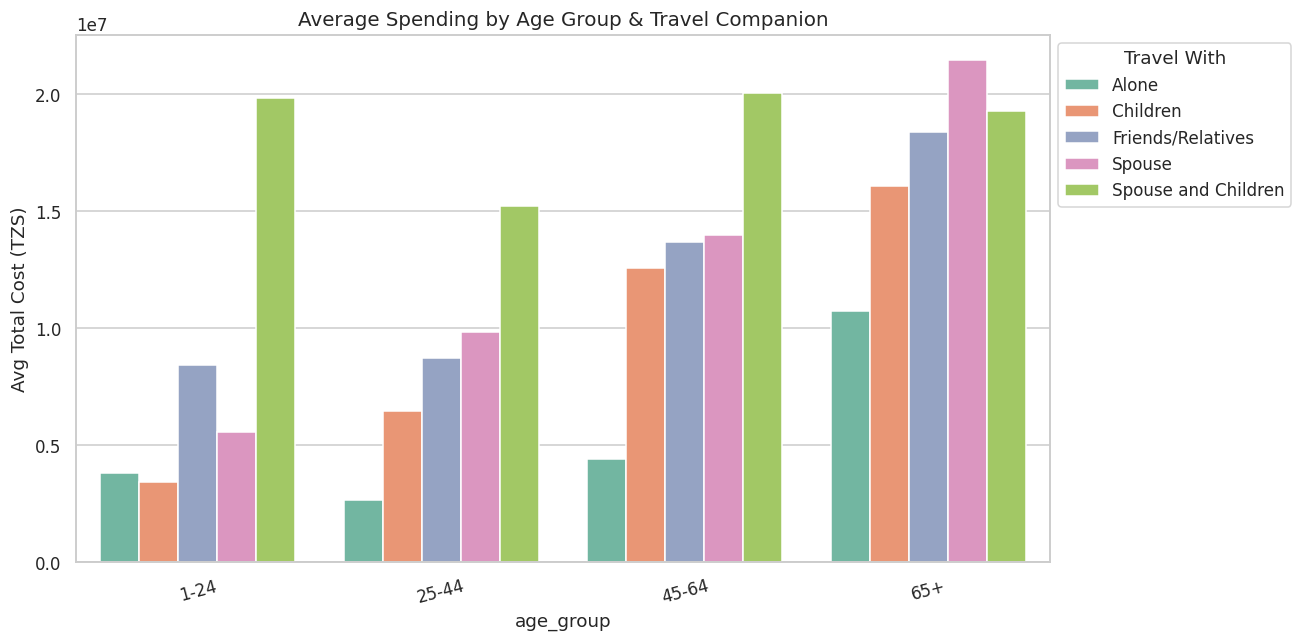

Key insight: Younger tourists (1-24) travelling with family/spouse
tend to generate higher spending, likely package family holidays.


In [23]:
plt.figure(figsize=(12, 6))
age_travel = tr_only.groupby(['age_group','travel_with'])['total_cost'].mean().reset_index()
sns.barplot(data=age_travel, x='age_group', y='total_cost', hue='travel_with',
            palette='Set2', order=['1-24','25-44','45-64','65+'])
plt.title('Average Spending by Age Group & Travel Companion', fontsize=13)
plt.ylabel('Avg Total Cost (TZS)')
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1, 1), title='Travel With')
plt.tight_layout(); plt.show()

print("Key insight: Younger tourists (1-24) travelling with family/spouse")
print("tend to generate higher spending, likely package family holidays.")


### 4.8 Night Stay Distribution by Destination

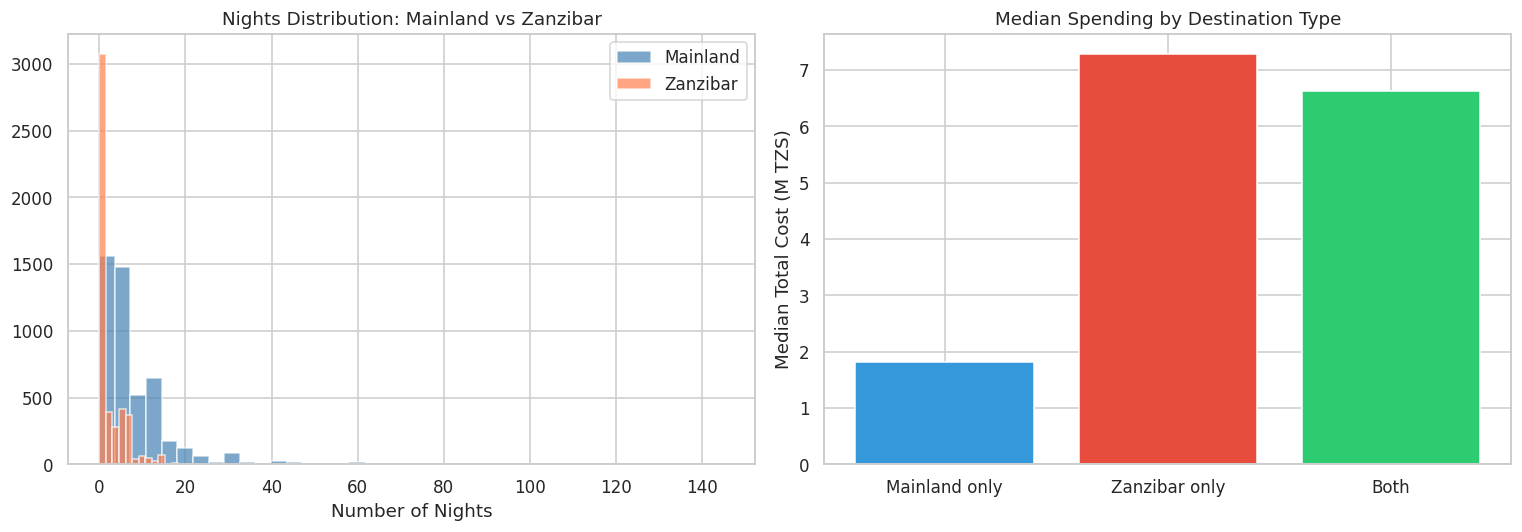

Tourists visiting both Mainland and Zanzibar spend significantly more.


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Night distributions
axes[0].hist(tr_only['night_mainland'].dropna(), bins=40, alpha=0.7,
             color='steelblue', label='Mainland', edgecolor='white')
axes[0].hist(tr_only['night_zanzibar'].dropna(), bins=40, alpha=0.7,
             color='coral', label='Zanzibar', edgecolor='white')
axes[0].set_title('Nights Distribution: Mainland vs Zanzibar')
axes[0].set_xlabel('Number of Nights'); axes[0].legend()

# Spending by destination type
dest_spend = {
    'Mainland only': tr_only.loc[(tr_only['night_mainland']>0) & (tr_only['night_zanzibar']==0), 'total_cost'].median(),
    'Zanzibar only': tr_only.loc[(tr_only['night_mainland']==0) & (tr_only['night_zanzibar']>0), 'total_cost'].median(),
    'Both':          tr_only.loc[(tr_only['night_mainland']>0) & (tr_only['night_zanzibar']>0), 'total_cost'].median(),
}
axes[1].bar(dest_spend.keys(), [v/1e6 for v in dest_spend.values()],
            color=['#3498db','#e74c3c','#2ecc71'], edgecolor='white')
axes[1].set_title('Median Spending by Destination Type')
axes[1].set_ylabel('Median Total Cost (M TZS)')

plt.tight_layout(); plt.show()
print("Tourists visiting both Mainland and Zanzibar spend significantly more.")


---
## 5. Feature Engineering Pipeline

### Requirement 4: Supervised ML model — CatBoost + LightGBM Regression Ensemble


In [25]:
# Package columns: Yes/No -> binary (needed before feature engineering)
pkg_cols = [c for c in combined.columns if c.startswith('package_')]
for col in pkg_cols:
    combined[col] = (combined[col] == 'Yes').astype(int)

# ── Geographic flags
AFRICAN_COUNTRIES = {
    'SOUTH AFRICA','NIGERIA','MOZAMBIQUE','RWANDA','KENYA','ALGERIA','EGYPT',
    'MALAWI','UGANDA','ZIMBABWE','ZAMBIA','CONGO','MAURITIUS','DRC','SWAZILAND',
    'TUNISIA','ETHIOPIA','BURUNDI','GHANA','NIGER','ANGOLA','CAPE VERDE','SUDAN',
    'NAMIBIA','LESOTHO','IVORY COAST','MADAGASCAR','DJIBOUT','MORROCO','BOTSWANA',
    'LIBERIA','GUINEA','SOMALI','COMORO','TANZANIA'
}
HIGH_INCOME_COUNTRIES = {
    'UNITED STATES OF AMERICA','UNITED KINGDOM','GERMANY','FRANCE','AUSTRALIA',
    'CANADA','SWITZERLAND','NETHERLANDS','SWEDEN','NORWAY','DENMARK','JAPAN',
    'SOUTH KOREA','SINGAPORE','NEW ZEALAND','AUSTRIA','BELGIUM','FINLAND',
    'IRELAND','ISRAEL','ITALY','LUXEMBOURG','SPAIN','PORTUGAL'
}

combined['is_african']     = combined['country'].isin(AFRICAN_COUNTRIES).astype(int)
combined['is_high_income'] = combined['country'].isin(HIGH_INCOME_COUNTRIES).astype(int)

# ── Trip aggregate features
combined['total_nights']      = combined['night_mainland'] + combined['night_zanzibar']
combined['total_packages']    = combined[pkg_cols].sum(axis=1)
combined['nights_ratio']      = combined['night_zanzibar'] / (combined['total_nights'] + 1)
combined['people_nights']     = combined['total_people'] * combined['total_nights']
combined['pkg_x_people']      = combined['total_packages'] * combined['total_people']
combined['pkg_x_nights']      = combined['total_packages'] * combined['total_nights']
combined['nights_per_person'] = combined['total_nights'] / (combined['total_people'] + 1e-3)
combined['female_ratio']      = combined['total_female'] / (combined['total_people'] + 1e-3)

# ── Binary flags
combined['is_package_tour'] = (combined['tour_arrangement'] == 'Package Tour').astype(int)
combined['is_first_trip']   = (combined['first_trip_tz'] == 'Yes').astype(int)
combined['has_zanzibar']    = (combined['night_zanzibar'] > 0).astype(int)
combined['is_solo']         = (combined['total_people'] == 1).astype(int)
combined['is_large_group']  = (combined['total_people'] >= 5).astype(int)
combined['is_long_stay']    = (combined['total_nights'] >= 14).astype(int)
combined['high_pkg_count']  = (combined['total_packages'] >= 4).astype(int)

# ── Log-scale features (handle non-linear magnitude)
combined['log_people']         = np.log1p(combined['total_people'])
combined['log_nights']         = np.log1p(combined['total_nights'])
combined['log_people_nights']  = np.log1p(combined['people_nights'])

# ── Interaction features
combined['premium_tourist'] = combined['is_high_income'] * combined['is_package_tour']
combined['premium_nights']  = combined['is_high_income'] * combined['total_nights']

cat_cols = ['country','age_group','travel_with','purpose','main_activity',
            'info_source','tour_arrangement','payment_mode','most_impressing']
for col in cat_cols:
    combined[col] = combined[col].astype(str)

print(f"Total features in combined: {combined.shape[1]}")
print(f"New engineered features: {combined.shape[1] - train_df.shape[1]}")


Total features in combined: 46
New engineered features: 23


## 6. Leak-Free Target Encoding

For each high-cardinality categorical, compute `mean(log1p(total_cost))`.  
Uses **5-fold cross-encoding** to prevent data leakage on training rows.


In [26]:
tr = combined[combined['total_cost'].notna()].copy()
te = combined[combined['total_cost'].isna()].copy()

kf_te       = KFold(n_splits=5, shuffle=True, random_state=42)
global_mean = np.log1p(tr['total_cost']).mean()

TE_COLS = ['country','age_group','purpose','main_activity',
           'travel_with','payment_mode','tour_arrangement','info_source']

for col in TE_COLS:
    tr[f'{col}_te'] = np.nan
    for tr_idx, val_idx in kf_te.split(tr):
        fold_mean = (np.log1p(tr.iloc[tr_idx]['total_cost'])
                     .groupby(tr.iloc[tr_idx][col]).mean())
        tr.iloc[val_idx, tr.columns.get_loc(f'{col}_te')] = (
            tr.iloc[val_idx][col].map(fold_mean).fillna(global_mean))
    full_mean = np.log1p(tr['total_cost']).groupby(tr[col]).mean()
    te[f'{col}_te'] = te[col].map(full_mean).fillna(global_mean)

# Country median TE (complementary signal)
tr['country_median_te'] = np.nan
for tr_idx, val_idx in kf_te.split(tr):
    fold_med = (np.log1p(tr.iloc[tr_idx]['total_cost'])
                .groupby(tr.iloc[tr_idx]['country']).median())
    tr.iloc[val_idx, tr.columns.get_loc('country_median_te')] = (
        tr.iloc[val_idx]['country'].map(fold_med).fillna(global_mean))
full_med = np.log1p(tr['total_cost']).groupby(tr['country']).median()
te['country_median_te'] = te['country'].map(full_med).fillna(global_mean)

DROP_COLS    = ['ID','total_cost','first_trip_tz','total_female','total_male',
                'night_mainland','night_zanzibar']
feature_cols = [c for c in tr.columns if c not in DROP_COLS]
cat_idx      = [feature_cols.index(c) for c in cat_cols if c in feature_cols]

X_all        = tr[feature_cols]
y_all        = np.log1p(tr['total_cost'])   # ← log1p transform applied here
X_test_final = te[feature_cols]
test_ids     = te['ID'].values

print(f"Total features   : {len(feature_cols)}")
print(f"Categorical feats: {len(cat_idx)}")
print(f"Training samples : {len(X_all)}")
print(f"Test samples     : {len(X_test_final)}")


Total features   : 48
Categorical feats: 9
Training samples : 4809
Test samples     : 1601


In [27]:
# Label encoding for LightGBM
X_all_enc  = X_all.copy()
X_test_enc = X_test_final.copy()

for col in cat_cols:
    if col in X_all_enc.columns:
        le = LabelEncoder()
        X_all_enc[col]  = le.fit_transform(X_all_enc[col].astype(str))
        X_test_enc[col] = X_test_enc[col].astype(str).map(
            lambda x: le.transform([x])[0] if x in le.classes_ else -1)

print("Label encoding complete for LightGBM.")


Label encoding complete for LightGBM.


## 7. Model Training

### Why these models?
- **CatBoost**: handles categorical features natively; optimises directly for MAE;  
  fast on small-to-medium datasets; robust to hyperparameter choices.
- **LightGBM**: leaf-wise tree growth captures complex interactions;  
  different inductive bias from CatBoost → blend improves over either alone.
- **Ensemble**: averaging diverse models reduces variance without sacrificing bias.

### 7.1 CatBoost Ensemble (3 configs × 5 folds = 15 models)


In [28]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

CAT_CONFIGS = [
    {'bagging_temperature': 0.5, 'colsample_bylevel': 0.8},
    {'bagging_temperature': 0.7, 'colsample_bylevel': 0.9},
    {'bagging_temperature': 0.9, 'colsample_bylevel': 0.7},
]

oof_cat  = np.zeros(len(X_all))
test_cat = np.zeros(len(X_test_final))

print("Training CatBoost: 3 configs × 5 folds = 15 models")
print("-" * 55)

for cfg_i, cfg in enumerate(CAT_CONFIGS):
    oof_tmp  = np.zeros(len(X_all))
    test_tmp = np.zeros(len(X_test_final))

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_all)):
        m = CatBoostRegressor(
            iterations            = 3000,
            depth                 = 7,
            loss_function         = 'MAE',
            eval_metric           = 'MAE',
            learning_rate         = 0.03,
            random_seed           = fold * 10 + cfg_i + 1,
            cat_features          = cat_idx,
            logging_level         = 'Silent',
            early_stopping_rounds = 200,
            l2_leaf_reg           = 3,
            **cfg
        )
        m.fit(X_all.iloc[tr_idx], y_all.iloc[tr_idx],
              eval_set=(X_all.iloc[val_idx], y_all.iloc[val_idx]))
        oof_tmp[val_idx] += m.predict(X_all.iloc[val_idx])
        test_tmp         += m.predict(X_test_final) / 5

    cfg_mae = mean_absolute_error(np.expm1(y_all), np.expm1(oof_tmp))
    print(f"  Config {cfg_i+1} OOF MAE: {cfg_mae:>12,.0f} TZS")
    oof_cat  += oof_tmp  / 3
    test_cat += test_tmp / 3

cat_mae = mean_absolute_error(np.expm1(y_all), np.expm1(oof_cat))
print("-" * 55)
print(f"CatBoost Ensemble OOF MAE: {cat_mae:>8,.0f} TZS")


Training CatBoost: 3 configs × 5 folds = 15 models
-------------------------------------------------------
  Config 1 OOF MAE:    4,704,738 TZS
  Config 2 OOF MAE:    4,716,155 TZS
  Config 3 OOF MAE:    4,706,739 TZS
-------------------------------------------------------
CatBoost Ensemble OOF MAE: 4,694,170 TZS


### 7.2 LightGBM (5-fold)

In [29]:
oof_lgb  = np.zeros(len(X_all))
test_lgb = np.zeros(len(X_test_final))
lgb_cat  = [c for c in cat_cols if c in X_all_enc.columns]

print("Training LightGBM (5-fold)")
print("-" * 55)

LGB_PARAMS = dict(
    objective='mae', metric='mae', num_leaves=127, learning_rate=0.02,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    lambda_l1=0.1, lambda_l2=1.0, min_child_samples=15, verbose=-1,
)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_all)):
    LGB_PARAMS['seed'] = fold * 7
    dtrain = lgb.Dataset(X_all_enc.iloc[tr_idx], y_all.iloc[tr_idx],
                         categorical_feature=lgb_cat)
    dval   = lgb.Dataset(X_all_enc.iloc[val_idx], y_all.iloc[val_idx],
                         categorical_feature=lgb_cat)
    m = lgb.train(
        LGB_PARAMS, dtrain, num_boost_round=4000, valid_sets=[dval],
        callbacks=[lgb.early_stopping(300, verbose=False), lgb.log_evaluation(-1)]
    )
    oof_lgb[val_idx] = m.predict(X_all_enc.iloc[val_idx])
    test_lgb        += m.predict(X_test_enc) / 5

    mae = mean_absolute_error(np.expm1(y_all.iloc[val_idx]),
                              np.expm1(m.predict(X_all_enc.iloc[val_idx])))
    print(f"  Fold {fold+1}: {mae:>12,.0f} TZS | best iter: {m.best_iteration}")

lgb_mae = mean_absolute_error(np.expm1(y_all), np.expm1(oof_lgb))
print("-" * 55)
print(f"LightGBM OOF MAE: {lgb_mae:>10,.0f} TZS")


Training LightGBM (5-fold)
-------------------------------------------------------
  Fold 1:    4,494,375 TZS | best iter: 255
  Fold 2:    4,451,392 TZS | best iter: 408
  Fold 3:    5,221,360 TZS | best iter: 422
  Fold 4:    4,538,323 TZS | best iter: 332
  Fold 5:    5,054,659 TZS | best iter: 391
-------------------------------------------------------
LightGBM OOF MAE:  4,751,959 TZS


### 7.3 Optimised Weighted Blend

In [30]:
print("Sweeping blend weights on OOF predictions (no leakage):")
print("-" * 55)
best_mae, best_w = np.inf, 0.5

for w_cat in np.arange(0.50, 0.86, 0.05):
    blend = w_cat * oof_cat + (1 - w_cat) * oof_lgb
    mae   = mean_absolute_error(np.expm1(y_all), np.expm1(blend))
    mark  = " <-- BEST" if mae < best_mae else ""
    print(f"  CatBoost={w_cat:.2f}, LGB={1-w_cat:.2f}  |  OOF MAE: {mae:>10,.0f}{mark}")
    if mae < best_mae:
        best_mae, best_w = mae, w_cat

print("-" * 55)
print(f"Best blend: CatBoost={best_w:.2f}, LGB={1-best_w:.2f}")
print(f"Best OOF MAE: {best_mae:>10,.0f} TZS")


Sweeping blend weights on OOF predictions (no leakage):
-------------------------------------------------------
  CatBoost=0.50, LGB=0.50  |  OOF MAE:  4,691,652 <-- BEST
  CatBoost=0.55, LGB=0.45  |  OOF MAE:  4,689,025 <-- BEST
  CatBoost=0.60, LGB=0.40  |  OOF MAE:  4,686,811 <-- BEST
  CatBoost=0.65, LGB=0.35  |  OOF MAE:  4,685,157 <-- BEST
  CatBoost=0.70, LGB=0.30  |  OOF MAE:  4,684,131 <-- BEST
  CatBoost=0.75, LGB=0.25  |  OOF MAE:  4,683,810 <-- BEST
  CatBoost=0.80, LGB=0.20  |  OOF MAE:  4,684,441
  CatBoost=0.85, LGB=0.15  |  OOF MAE:  4,685,628
-------------------------------------------------------
Best blend: CatBoost=0.75, LGB=0.25
Best OOF MAE:  4,683,810 TZS


## 8. Model Evaluation & Feature Importance

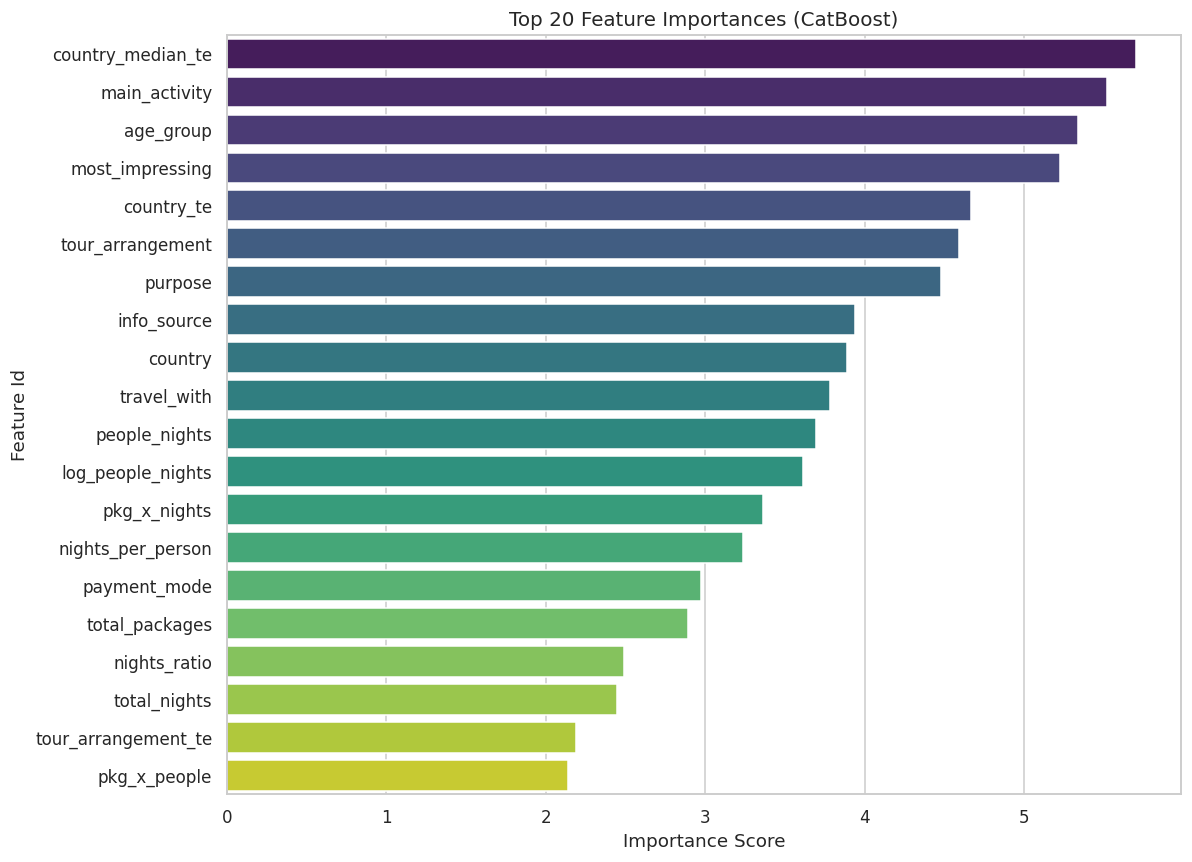

Top 10 most important features:
       Feature Id  Importances
country_median_te     5.700172
    main_activity     5.520509
        age_group     5.335799
  most_impressing     5.226790
       country_te     4.664520
 tour_arrangement     4.592697
          purpose     4.477127
      info_source     3.938216
          country     3.891091
      travel_with     3.781538


In [31]:
# Train a single CatBoost on full data for feature importance
model_full = CatBoostRegressor(
    iterations=3000, depth=7, loss_function='MAE',
    learning_rate=0.03, random_seed=42,
    cat_features=cat_idx, logging_level='Silent'
)
model_full.fit(X_all, y_all)

feat_imp = model_full.get_feature_importance(prettified=True)
top20    = feat_imp.head(20)

plt.figure(figsize=(11, 8))
sns.barplot(x='Importances', y='Feature Id', data=top20, palette='viridis')
plt.title('Top 20 Feature Importances (CatBoost)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()

print("Top 10 most important features:")
print(top20[['Feature Id','Importances']].head(10).to_string(index=False))


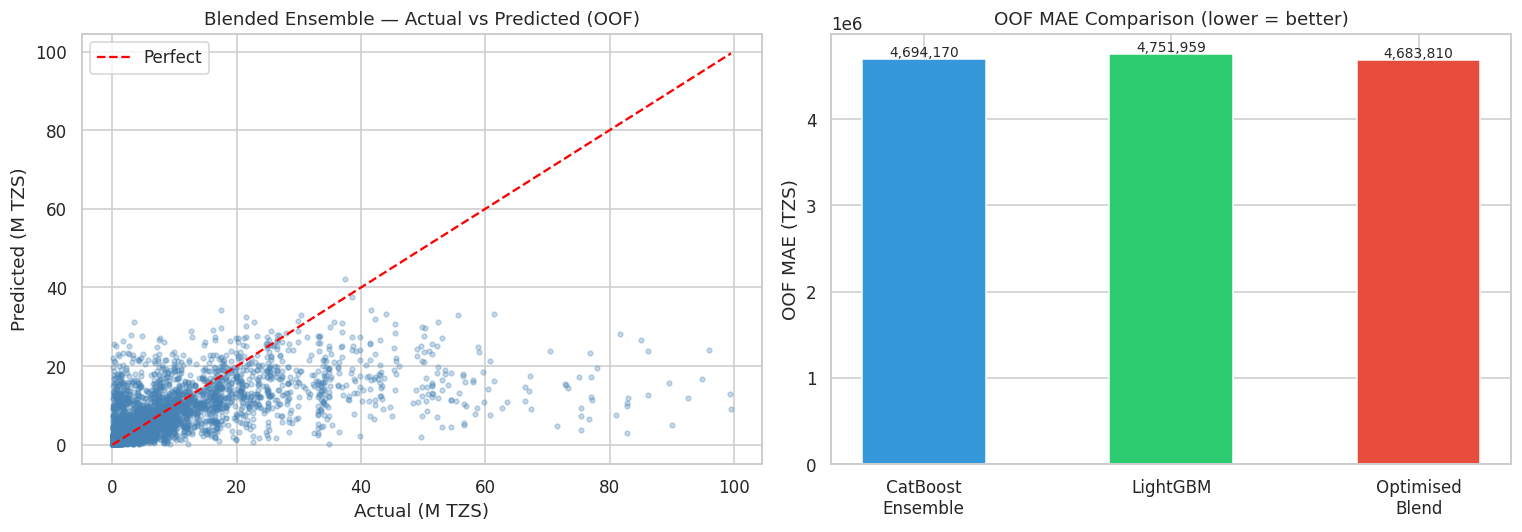

Metric                         Value
-------------------------------------
OOF MAE                 4,683,810 TZS
OOF RMSE                9,871,334 TZS
OOF R²                        0.3478


In [34]:
# Actual vs Predicted + Model comparison
best_oof = best_w * oof_cat + (1 - best_w) * oof_lgb
y_true   = np.expm1(y_all)
y_pred   = np.expm1(best_oof)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_true/1e6, y_pred/1e6, alpha=0.3, s=10, color='steelblue')
lim = max(y_true.max(), y_pred.max()) / 1e6
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect')
axes[0].set_xlabel('Actual (M TZS)'); axes[0].set_ylabel('Predicted (M TZS)')
axes[0].set_title('Blended Ensemble — Actual vs Predicted (OOF)')
axes[0].legend()

models_l  = ['''CatBoost
Ensemble''', 'LightGBM', '''Optimised
Blend''']
maes_l    = [cat_mae, lgb_mae, best_mae]
colors_l  = ['#3498db', '#2ecc71', '#e74c3c']
bars = axes[1].bar(models_l, maes_l, color=colors_l, edgecolor='white', width=0.5)
axes[1].set_ylabel('OOF MAE (TZS)')
axes[1].set_title('OOF MAE Comparison (lower = better)')
for bar, v in zip(bars, maes_l):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 30000,
                 f'{v:,.0f}', ha='center', fontsize=9)

plt.tight_layout(); plt.show()

final_r2   = r2_score(y_true, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"{'Metric':<20} {'Value':>15}")
print("-" * 37)
print(f"{'OOF MAE':<20} {best_mae:>12,.0f} TZS")
print(f"{'OOF RMSE':<20} {final_rmse:>12,.0f} TZS")
print(f"{'OOF R²':<20} {final_r2:>15.4f}")

## 9. Final Submission

Submission shape: (1601, 2)

Prediction statistics:
count         1,601
mean      6,251,997
std       6,410,353
min          96,471
25%       1,075,350
50%       3,941,990
75%       9,860,614
max      33,934,918
Name: total_cost, dtype: object


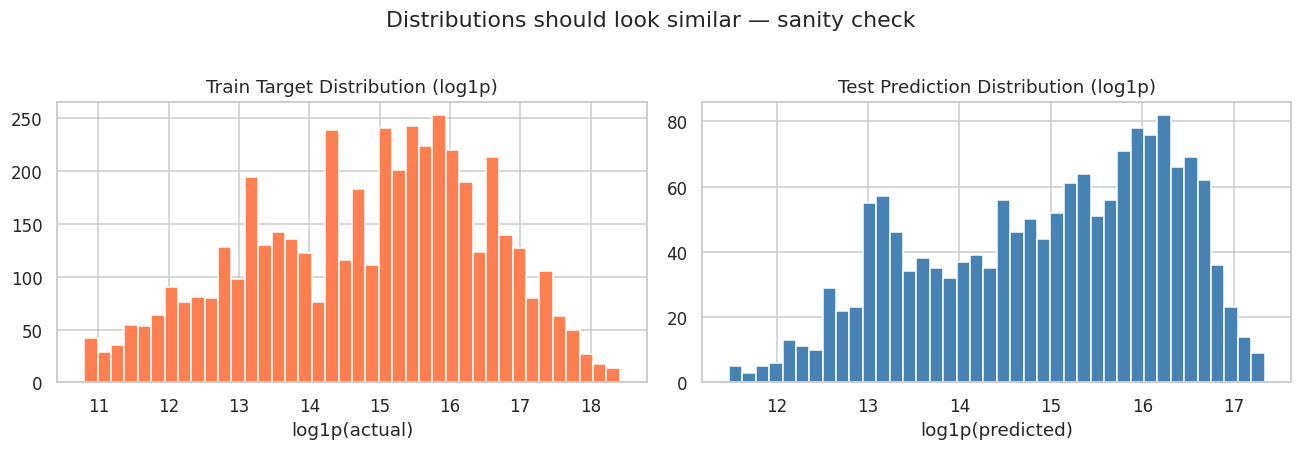


submission.csv saved! Upload to Zindi.
       ID   total_cost
   tour_1 1.875802e+07
 tour_100 8.363422e+06
tour_1001 6.320854e+06
tour_1006 1.487201e+06
tour_1009 1.934626e+07
tour_1010 1.697772e+06
tour_1014 4.615164e+06
tour_1015 1.742013e+06
tour_1019 8.021161e+05
tour_1020 4.943574e+06


In [35]:
final_preds = np.expm1(best_w * test_cat + (1 - best_w) * test_lgb)
submission  = pd.DataFrame({'ID': test_ids, 'total_cost': final_preds})

print("Submission shape:", submission.shape)
print("\nPrediction statistics:")
print(submission['total_cost'].describe().map('{:,.0f}'.format))

# Distribution sanity check
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.log1p(train_df['total_cost']), bins=40, color='coral', edgecolor='white')
axes[0].set_title('Train Target Distribution (log1p)')
axes[0].set_xlabel('log1p(actual)')

axes[1].hist(np.log1p(submission['total_cost']), bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Test Prediction Distribution (log1p)')
axes[1].set_xlabel('log1p(predicted)')

plt.suptitle('Distributions should look similar — sanity check', y=1.02)
plt.tight_layout(); plt.show()

submission.to_csv('submission.csv', index=False)
print("\nsubmission.csv saved! Upload to Zindi.")
print(submission.head(10).to_string(index=False))


## 10. Project Summary

### Requirements Coverage

| Requirement | What was done |
|-------------|---------------|
| **1a — Missing values** | Gender counts imputed with country-level mean; `travel_with`, `most_impressing`, `first_trip_tz` filled by logic/mode |
| **1b — Outliers** | IQR fence detection (3×IQR); Isolation Forest for multivariate outliers; treatment via log1p transform |
| **1c — Class imbalance** | Target is heavily right-skewed; treated with log1p transformation and Q-Q plot validation |
| **1d — Transformations** | log1p(target), binary encoding (packages), label encoding, 5-fold leak-free target encoding |
| **2 — Dataset problems** | Problem 1: `age_group` Excel date artefact ('24-Jan' → '1-24'); Problem 2: inconsistent `travel_with` for solo travellers |
| **3 — EDA** | 8 visualisation sections: distributions, Q-Q plots, correlation heatmaps, categorical breakdowns, country analysis, package analysis, interaction plots, destination analysis |
| **4 — ML model** | Supervised regression: CatBoost ensemble (15 models) + LightGBM (5-fold) with optimised blend; 5-fold OOF validation; feature importance analysis |

### Key Findings
- Group size (`total_people`, `people_nights`) is the strongest predictor
- High-income country tourists on package tours spend 3–5× more
- Visiting both Mainland and Zanzibar doubles median expenditure
- Log1p target transformation reduces skewness from >5 to near 0
